# ANN for regression_Model_2
### Dataset name is "California Housing Prices"
### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)
### The dataset is 20.6K rows, can be considered as a medium dataset. It contains 7 numeric columns, 2 columns with coordinates, and one column with categorical value - text values. The target variable is "median house value". 
#### In this model i will remove high-value outliers of the target variable

In [66]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

## Loading the dataset

In [67]:
# load data 
df = pd.read_csv("housing.csv")

In [68]:
# According to CharGPT is it enouth for small ANN model, good enough to learn basic patterns. 
len(df)

20640

In [69]:
# the dataset has 10 clolumns, and one "ocean_proximity" is categorical. I will need to encode it properly (one-hot encoding)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: >

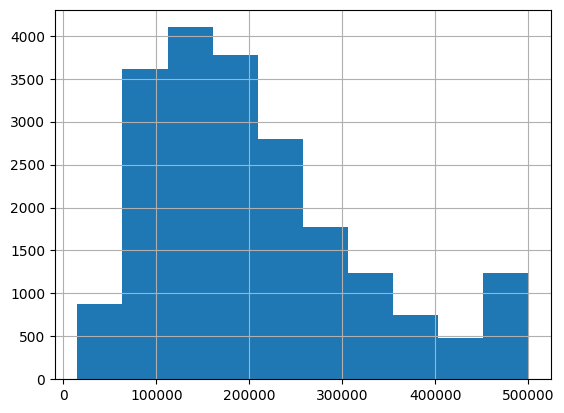

In [70]:
# this plot shows that the target variable is right-skewed, there's a smaller group of homes with very high price, this tail indicates high-value homes
# let's remove the outliers for better model performance
df['median_house_value'].hist()

In [71]:
# we will use quantiles to remove the top % in order to get closer to normal distribution
df = df.query("median_house_value < median_house_value.quantile(0.93)")

<Axes: >

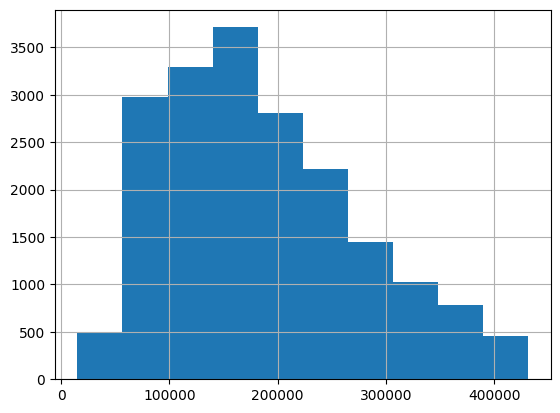

In [72]:
# now it looks better:
df['median_house_value'].hist()

In [73]:
# check if we have any missing values
df.isna().sum()

# we have missing values. I cannot fill them with median value as depends on how big a house is. I will drop them for now, not later will check how it will affect the results.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        196
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [74]:
# dropping rows with missing values
df = df.dropna()

In [75]:
df.isna().sum()

# now we don't have any missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [76]:
# check duplicates
int(df.duplicated().sum())

# no duplicates

0

## Handling the categorical variables

In [77]:
# "ocean_proximity" is nominal categorical variable, I will use one-hot encoding to convert it to numerical
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [78]:
# by using encoder we will add 5 new columns, but will remove one -  and the original one.
from sklearn.preprocessing import OneHotEncoder
variables = ['ocean_proximity']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [79]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1,0


In [80]:
# dropping the last variable:
df = df.drop("ocean_proximity_NEAR OCEAN", axis=1)

In [81]:
# let's check:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,0,0,0,1


### Let's check the correlation between the features against each other and check distribution of support variables:

<Axes: >

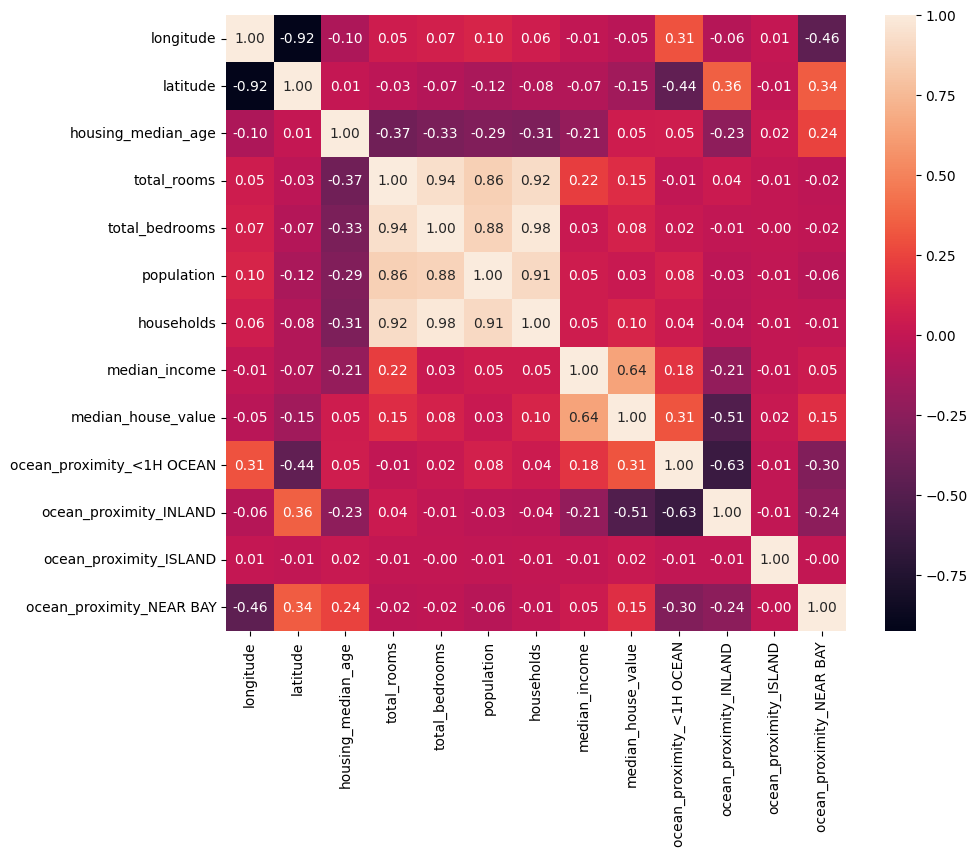

In [82]:
# it was difficult to see numbers, so we will increase the figure size:
plt.figure(figsize=(10, 8))

# on this correlation matrix we can see the most important supported variables:
# median_income. 
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')

### Support variables based on correlations are: "median_income" and "ocean_proximity_<1H OCEAN" but the last has poor connection, just 0.26.

<Axes: xlabel='median_income', ylabel='Count'>

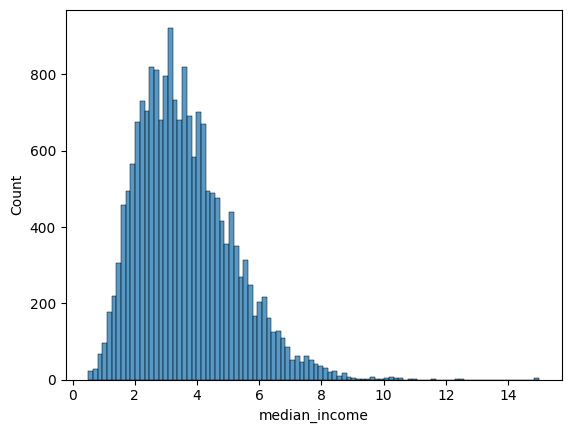

In [83]:
# let's check the distribution of median_income
sns.histplot(df['median_income'])

# this time I will remove the outliers above 99%

In [84]:
df = df.query("median_income < median_income.quantile(0.99)")

<Axes: xlabel='median_income', ylabel='Count'>

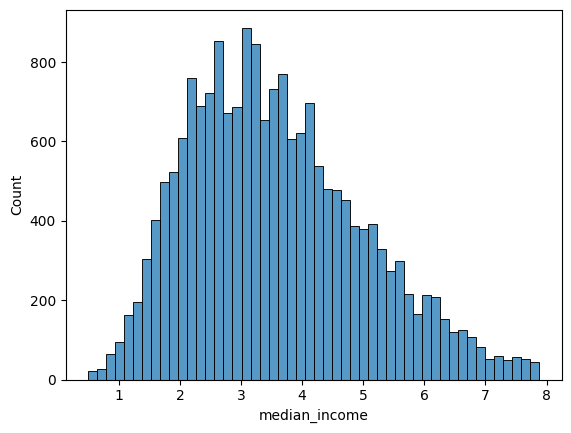

In [85]:
# looks also better:
sns.histplot(df['median_income'])

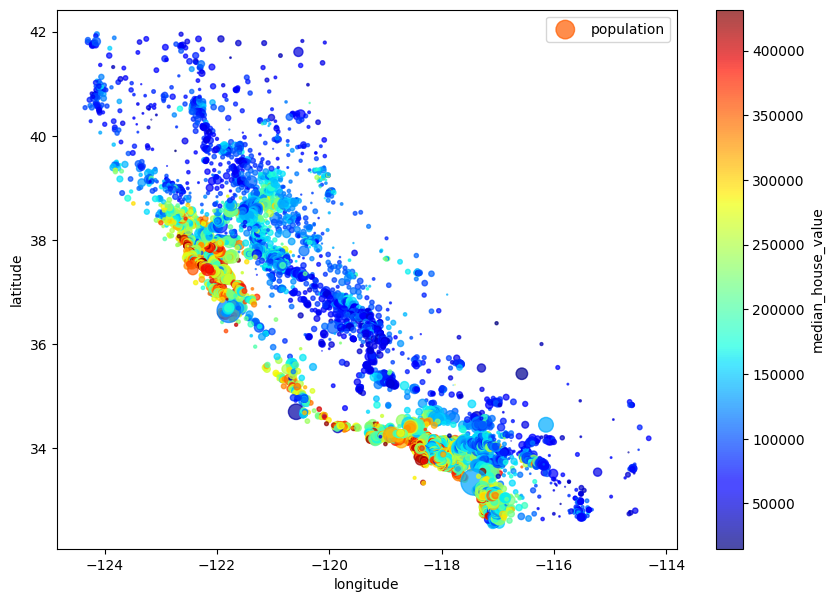

In [86]:
# let's check coordinates against the target variable:

df.plot(kind="scatter", x="longitude",y="latitude", c="median_house_value", cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10,7), s=df['population']/100, label="population", alpha=0.7)
plt.show()

# We can see that houses near ocean are the most expensive but there are some outliers,
# and we can spot two big cities Los Angeles and San Francisco, where expensive houses concentrate.
# I will create second Jupyter notebook, where I will add distances to these cities as new features.
# We can check if it will improve the model as it will give the model deeper understanding how prices of houses are formed.    


# Ref:https://medium.com/@basumatary18/implementing-linear-regression-on-california-housing-dataset-378e14e421b7#id_token=eyJhbGciOiJSUzI1NiIsImtpZCI6ImZhMDcyZjc1Nzg0NjQyNjE1MDg3YzcxODJjMTAxMzQxZTE4ZjdhM2EiLCJ0eXAiOiJKV1QifQ.eyJpc3MiOiJodHRwczovL2FjY291bnRzLmdvb2dsZS5jb20iLCJhenAiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJhdWQiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJzdWIiOiIxMTgyMDUxMTQ5NTgzODQ3NTcwODkiLCJlbWFpbCI6InN2ZXRsYW5hLmVtZGVuQGdtYWlsLmNvbSIsImVtYWlsX3ZlcmlmaWVkIjp0cnVlLCJuYmYiOjE3MzgzNTkyNTIsIm5hbWUiOiJTdmV0bGFuYSBFbWRlbi1CYXpoZW5vdmEiLCJwaWN0dXJlIjoiaHR0cHM6Ly9saDMuZ29vZ2xldXNlcmNvbnRlbnQuY29tL2EvQUNnOG9jTDVVOF81dTBRZGk1U0Z0QllIZFJwTFNRSDZkVkxTSTd2ejMxTUZQMTl4YjB0bnB3PXM5Ni1jIiwiZ2l2ZW5fbmFtZSI6IlN2ZXRsYW5hIiwiZmFtaWx5X25hbWUiOiJFbWRlbi1CYXpoZW5vdmEiLCJpYXQiOjE3MzgzNTk1NTIsImV4cCI6MTczODM2MzE1MiwianRpIjoiYzA1NDJiMDQ0YTMyODNjYThlN2Q2ZWZiZmRmYmI2NDExNDkxMDY4OSJ9.KE4D73fy_EXA0kP-cJkQAHDdDEp4eazJhRuFk3vIPBg7aC5x5Iia0IfOjjpmjfrVDKFrHOgujPRKVyRZ-cd4_LW2jffKnM4e5ZkzQLk1dpwpiHhZXS9t9h6VMuNRv-a6cEDu0wVR1oCj13sVVSua6sxu2cxvi74kV8dDftV6Ke_ve8XshVWRy2yEm4TBp42MphTQJQWJOlpAoy31CTqM6upLSUnYatnbIfbUVqwwJbyIP7TylHEqPKJHXFduj3Qdhi4edhUYc3pC5ahevpD2Im3kzAqOB3df6A6fRWB5c9Y9OAblTD3tiSYdmwBVDAZkK5fGIXrHD2jcUZ825_ZGQg 

In [103]:
# Let's check the length of df:
len(df)

18809

## X/y -split

In [88]:
# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("median_house_value", axis=1)

# have only the target variable here (dependent variable)
y = df["median_house_value"]

## Train/test/validation -split

In [89]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

## Create a neural network structure

In [90]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 

# Tip: have at least the same number of nodes as in the input shape

# since we have 13 support variables this time => 16 nodes in first layer

# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(128 , activation="relu", input_shape=(variable_amount,)),
        layers.Dropout(0.1),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
model.compile(optimizer='adam', loss='mse')

# common tips on how to change neural network structure if your metrics are not good:

# make wider (or narrower) layers (for example, 64 or 128 nodes)
# make a longer or shorter network (add or remove layers)
# use Dropout -layers (e.g. layers.Dropout(0.1))

# remember: there's no process or mathematical formula
# in order to figure out the optimal neural network structure
# it's mostly all about trial and error => EXPERIMENTATION!

# remember to have enough "decision-space" for your data!
# it's highly unlikely a dataset with 20 different variables is going
# to work well with only 8 nodes in each layer etc.

# print out the summary of your model
model.summary()

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

## Train the neural network

In [91]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=800, validation_data=(X_val, y_val))

Epoch 1/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 21832847360.0000 - val_loss: 15223994368.0000
Epoch 2/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11591746560.0000 - val_loss: 7163303424.0000
Epoch 3/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7295612416.0000 - val_loss: 6424583168.0000
Epoch 4/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6985467904.0000 - val_loss: 6203716608.0000
Epoch 5/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6864072704.0000 - val_loss: 6111982592.0000
Epoch 6/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6684739584.0000 - val_loss: 5909901312.0000
Epoch 7/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6456673792.0000 - val_loss: 5918377984.0000
Epoch 8/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6315323392.0000 - val_loss: 5618019840.0000
Epoch 9/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6128144384.0000 - val_loss: 5426792448.0000
Epoch 10/800
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

<Axes: >

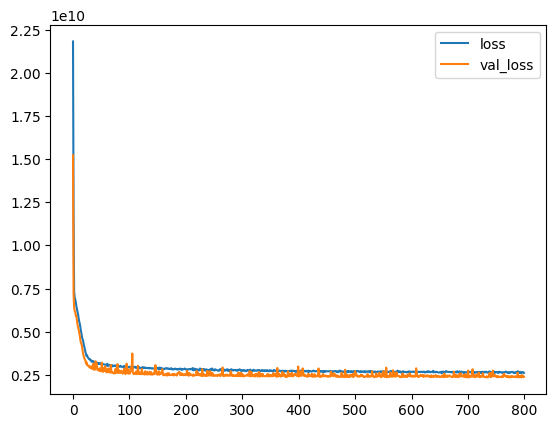

In [92]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [93]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
2540447232.0

Train data evaluation:
2329889024.0


### Based on the grapth above, the model's training and validation loss decreased rapidly during the first about 100 epochs, 
### THe model is no longer improving much after 200–250 epochs, so that is a sign that I could stop earlier training. There was no major difference between training and validation loss, meaning the model generalizes well without overfitting.

In [94]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Test True Y,Model Predictions
0,111100.0,132479.390625
1,171400.0,223961.812500
2,70200.0,102991.671875
3,206300.0,81763.687500
4,136900.0,180445.156250
...,...,...
2817,325000.0,263394.468750
2818,324600.0,349688.406250
2819,197400.0,226632.000000
2820,212200.0,266652.781250


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

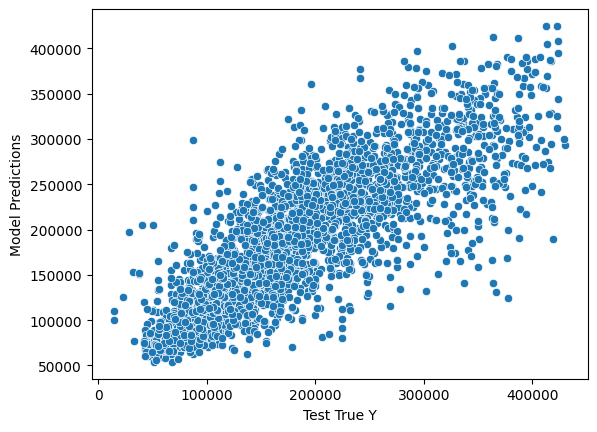

In [95]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [96]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "$")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "$^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "$")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
37661.11 $

MSE
2540447347.17 $^2

RMSE:
50402.85 $

R-squared:
0.67

Explained variance score:
0.67


C:\Users\svetl\AppData\Local\Temp\ipykernel_18028\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


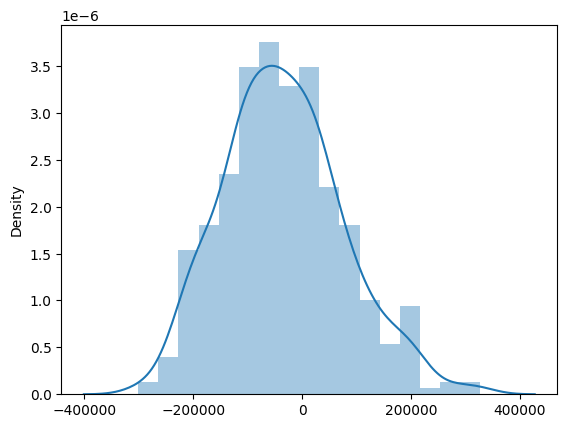

In [97]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

#### The prediction distribution looks like a  normal distribution, so it means that the model is balanced and well-performing. However, we can see tails on right and left that suggests that the model struggles with a few extreme cases — likely expensive homes.



## Trying the model in practice with new imaginary house

In [98]:
# just to see what kind of values are usually in the dataset
# so we can test with the tester_row
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1


In [99]:
# example row for testing
print(X.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY']


In [100]:
# let's try with some new imaginary data

tester_row = {
    'longitude': -122.22, 
    'latitude': 37.86, 
    'housing_median_age': 41.0, 
    'total_rooms': 880.0, 
    'total_bedrooms': 129.0,
    'population': 322.0, 
    'households': 126.0	, 
    'median_income': 8.3252, 
    'ocean_proximity_<1H OCEAN': 0,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [101]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Estimated house price with this example:")
print(f"$ {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Estimated house price with this example:
$ 415921.56
----------------


#### the model undersshoots the extimation, the price should be $ 452600.0 -> prediction is $ 407610.22  
### SUMMARY: 
#### In this model, I experimented with different input layer sizes to evaluate how network capacity affects performance. Using input layer -16 I got this results: R-squared: 0.67, prediction price is $ 377918.16. Using input layer 64: R-squared: 0.7 and prediction is $ 407610.22. This clearly shows that increasing the network's capacity (wider input layer) led to better performance and more accurate predictions. However, there is still some underestimation, this is likely influenced by the price cap effect and the presence of extreme values of target value. In this Model_1 I didn't remove extreme value of target variaable. In Model 2, I will: 1. Filter out extreme target values 2. Retrain the model using the same structure 3. Compare the performance metrics